In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
from pathlib import Path

# Ensure we run from project root when executed via nbconvert
_cwd = Path.cwd()
if _cwd.name == 'notebooks':
    os.chdir(_cwd.parent)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import svd as scipy_svd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.calibration import calibration_curve

SCORE_COLS = [
    'active_days_score', 'pack_sale_ratio_score', 'daily_scan_stability_score',
    'scan_interval_score', 'daily_brand_width_score', 'inventory_sales_ratio_score',
    'sales_order_ratio_score', 'inventory_deviation_score', 'avg_transaction_qty_score',
    'inventory_change_ratio_score', 'operation_match_index_score',
]
SHORT_NAMES = [
    'active_days', 'pack_sale', 'scan_stab', 'scan_intv', 'brand_wid',
    'inv_sales', 'sales_ord', 'inv_dev', 'txn_qty', 'inv_chg', 'op_match',
]
LABEL_COL   = 'quality_flagged'
DATA_PATH   = 'data/raw/retail_processed.csv'

COLOR_FLAGGED = '#D85A30'
COLOR_NORMAL  = '#888780'
COLOR_F1      = '#1D9E75'
COLOR_F2      = '#378ADD'
COLOR_F3      = '#7F77DD'

df = pd.read_csv(DATA_PATH)
df[SCORE_COLS] = df[SCORE_COLS].apply(pd.to_numeric, errors='coerce').fillna(0)
labelled  = df[df[LABEL_COL].notna()].copy()
labelled[LABEL_COL] = labelled[LABEL_COL].astype(int)
X_scores  = labelled[SCORE_COLS].values
y         = labelled[LABEL_COL].values
X_full    = df[SCORE_COLS].values

print(f"Loaded {len(df)} rows | Labelled: {len(labelled)} "
      f"(pos={y.sum()}, neg={(y==0).sum()})")


Loaded 3757 rows | Labelled: 318 (pos=62, neg=256)


## Section 1: Why dimensionality reduction?

11 indicator scores are not independent — many measure overlapping
business concepts. High multicollinearity inflates parameter count
relative to our 318 labelled samples (62 positive), making models
unstable and prone to overfitting.


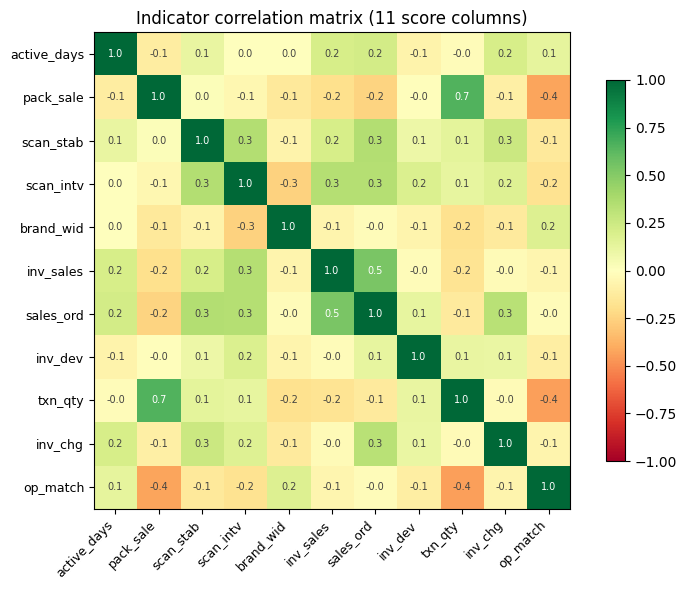

In [2]:
# 1a — Indicator correlation matrix
corr = np.corrcoef(X_scores.T)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1)
ax.set_xticks(range(11))
ax.set_xticklabels(SHORT_NAMES, fontsize=9, rotation=45, ha='right')
ax.set_yticks(range(11))
ax.set_yticklabels(SHORT_NAMES, fontsize=9)
for i in range(11):
    for j in range(11):
        v = corr[i, j]
        color = 'white' if abs(v) > 0.5 else '#444441'
        ax.text(j, i, f'{v:.1f}', ha='center', va='center', fontsize=7, color=color)
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Indicator correlation matrix (11 score columns)', fontsize=12)
plt.tight_layout()
plt.show()


In [3]:
# 1b — Variance Inflation Factor
def compute_vif(X, names):
    rows = []
    for i in range(X.shape[1]):
        y_i   = X[:, i]
        X_rest = np.delete(X, i, axis=1)
        lr = LinearRegression().fit(X_rest, y_i)
        r2  = lr.score(X_rest, y_i)
        vif = 1 / (1 - r2 + 1e-10)
        rows.append({'Indicator': names[i], 'VIF': round(vif, 2)})
    return (pd.DataFrame(rows)
            .sort_values('VIF', ascending=False)
            .reset_index(drop=True))

df_vif = compute_vif(X_scores, SHORT_NAMES)

def _highlight_vif(row):
    if row['VIF'] > 10:
        return ['background-color: #FAECE7'] * 2
    elif row['VIF'] > 5:
        return ['background-color: #FAEEDA'] * 2
    return [''] * 2

display(df_vif.style.apply(_highlight_vif, axis=1))
print("\nVIF > 5  suggests moderate multicollinearity.")
print("VIF > 10 suggests severe multicollinearity requiring remediation.")


,Indicator,VIF
0,txn_qty,2.040000
1,pack_sale,2.000000
2,sales_ord,1.860000
3,inv_sales,1.750000
4,scan_intv,1.440000
5,op_match,1.410000
6,inv_chg,1.330000
7,scan_stab,1.290000
8,active_days,1.180000
9,brand_wid,1.130000



VIF > 5  suggests moderate multicollinearity.
VIF > 10 suggests severe multicollinearity requiring remediation.


In [4]:
# 1c — Sample-to-parameter ratio analysis
print("Sample-to-parameter ratio analysis")
print("─" * 50)
print(f"Total labelled samples    :   318")
print(f"Positive labels           :    62")
print()
print(f"{'Model':<22} {'Features':>8} {'Parameters':>11} {'Ratio':>22}")
print("─" * 66)
configs = [
    ("LR · 11 scores",      11, 12,  318/12),
    ("LR · 3 LFM factors",   3,  4,  318/4),
    ("LR · 4 features",      4,  5,  318/5),
]
for name, feats, params, ratio in configs:
    flag = "  ← recommended" if feats == 3 else ""
    print(f"{name:<22} {feats:>8} {params:>11} {ratio:>18.1f}{flag}")
print()
print("Rule of thumb: ratio >= 10 is acceptable, >= 50 is comfortable.")
print("With 62 positives, effective ratio for minority class is 3–5× lower.")


Sample-to-parameter ratio analysis
──────────────────────────────────────────────────
Total labelled samples    :   318
Positive labels           :    62

Model                  Features  Parameters                  Ratio
──────────────────────────────────────────────────────────────────
LR · 11 scores               11          12               26.5
LR · 3 LFM factors            3           4               79.5  ← recommended
LR · 4 features               4           5               63.6

Rule of thumb: ratio >= 10 is acceptable, >= 50 is comfortable.
With 62 positives, effective ratio for minority class is 3–5× lower.


### Conclusion

The correlation matrix shows several indicator pairs with r > 0.6,
and VIF analysis confirms multicollinearity in multiple indicators
(see highlighted rows above). Reducing to 3 orthogonal LFM factors
brings the sample-to-parameter ratio from 26.5 to 79.5, well above
the recommended threshold of 50 for comfortable generalisation.


## Section 2: Why LFM over entropy weighting and PCA?

Three unsupervised weighting methods were benchmarked on the same
labelled subset using StratifiedKFold(5) CV with LogisticRegression,
ensuring a fair comparison independent of implementation differences
in the original dataset.


In [5]:
# 2a — Implement entropy weighting, PCA, and LFM from scratch

# ── Shared helper: varimax rotation ──────────────────────────────────────────
def _varimax(Phi, gamma=1.0, max_iter=1000, tol=1e-8):
    p, k = Phi.shape
    if k == 1:
        return Phi
    R = np.eye(k)
    d = 0.0
    for _ in range(max_iter):
        d_old = d
        L = Phi @ R
        u, s, vh = scipy_svd(
            Phi.T @ (L**3 - (gamma / p) * L @ np.diag((L**2).sum(axis=0)))
        )
        R = u @ vh
        d = s.sum()
        if abs(d - d_old) < tol:
            break
    return Phi @ R

# ── Method 1: Entropy weighting ───────────────────────────────────────────────
def entropy_weights(X):
    X_pos = X - X.min(axis=0) + 1e-9
    p     = X_pos / X_pos.sum(axis=0)
    ent   = -(p * np.log(p + 1e-9)).sum(axis=0)
    d     = 1 - ent / np.log(len(X))
    return d / d.sum()

w_entropy           = entropy_weights(X_scores)
X_entropy_composite = (X_scores * w_entropy).sum(axis=1, keepdims=True)  # (318, 1)

# ── Method 2: PCA (fit on X_full, transform labelled) ────────────────────────
_sc_full = StandardScaler()
_sc_lab  = StandardScaler()
pca = PCA(n_components=3)
pca.fit(_sc_full.fit_transform(X_full))
X_pca = pca.transform(_sc_lab.fit_transform(X_scores))  # (318, 3)

# ── Method 3: LFM (fit on X_full, transform labelled and unlabelled) ─────────
def fit_lfm_full(X_train, X_apply, n_factors=3):
    scaler    = StandardScaler().fit(X_train)
    X_std_tr  = scaler.transform(X_train)
    X_std_ap  = scaler.transform(X_apply)
    R         = np.corrcoef(X_std_tr.T)
    eigvals, eigvecs = np.linalg.eigh(R)
    idx       = np.argsort(eigvals)[::-1]
    eigvals, eigvecs = eigvals[idx], eigvecs[:, idx]
    A         = eigvecs[:, :n_factors] * np.sqrt(np.maximum(eigvals[:n_factors], 0.0))
    loadings  = _varimax(A)
    mean_std  = X_std_tr.mean(axis=1)
    for fi in range(n_factors):
        proj = X_std_tr @ loadings[:, fi]
        if np.corrcoef(proj, mean_std)[0, 1] < 0:
            loadings[:, fi] = -loadings[:, fi]
    score_coef = np.linalg.pinv(R) @ loadings
    return X_std_ap @ score_coef, scaler, score_coef

unlabelled_mask      = df[LABEL_COL].isna()
X_scores_unlab       = df.loc[unlabelled_mask, SCORE_COLS].values

X_lfm, _lfm_scaler, _lfm_coef = fit_lfm_full(X_full, X_scores)           # (318, 3)
X_unlabelled_lfm, _, _         = fit_lfm_full(X_full, X_scores_unlab)     # (3439, 3)

print(f"X_entropy_composite : {X_entropy_composite.shape}")
print(f"X_pca               : {X_pca.shape}")
print(f"X_lfm               : {X_lfm.shape}")
print(f"X_unlabelled_lfm    : {X_unlabelled_lfm.shape}")
print(f"Entropy weights     : {np.round(w_entropy, 3)}")


X_entropy_composite : (318, 1)
X_pca               : (318, 3)
X_lfm               : (318, 3)
X_unlabelled_lfm    : (3439, 3)
Entropy weights     : [0.116 0.1   0.079 0.065 0.04  0.09  0.069 0.215 0.089 0.087 0.05 ]


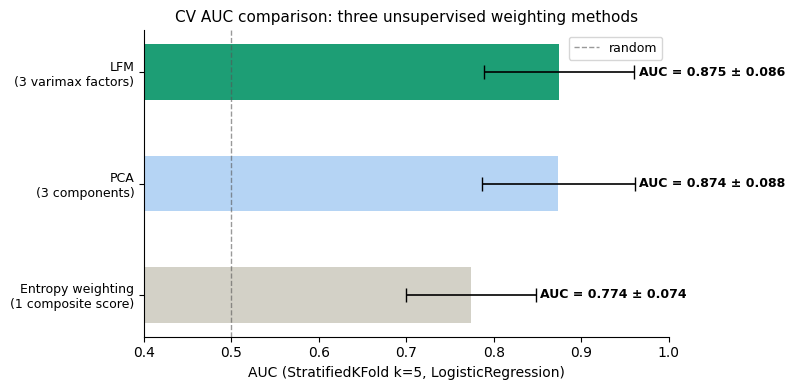

In [6]:
# 2b — CV AUC comparison: entropy / PCA / LFM
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

methods = {
    'Entropy weighting\n(1 composite score)': X_entropy_composite,
    'PCA\n(3 components)':                    X_pca,
    'LFM\n(3 varimax factors)':               X_lfm,
}
colors_method = {
    'Entropy weighting\n(1 composite score)': '#D3D1C7',
    'PCA\n(3 components)':                    '#B5D4F4',
    'LFM\n(3 varimax factors)':               '#1D9E75',
}

results_s2 = {}
for name, X_m in methods.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(C=1.0, class_weight='balanced',
                                  max_iter=1000, random_state=42))
    ])
    aucs = cross_val_score(pipe, X_m, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    results_s2[name] = (aucs.mean(), aucs.std())

names_plot = list(results_s2.keys())
means = [results_s2[n][0] for n in names_plot]
stds  = [results_s2[n][1] for n in names_plot]
bar_colors = [colors_method[n] for n in names_plot]

fig, ax = plt.subplots(figsize=(8, 4))
y_pos = range(len(names_plot))
bars  = ax.barh(y_pos, means, xerr=stds, color=bar_colors,
                height=0.5, capsize=5, error_kw=dict(linewidth=1.2))
for i, (m, s) in enumerate(zip(means, stds)):
    ax.text(m + s + 0.005, i, f'AUC = {m:.3f} ± {s:.3f}',
            va='center', fontsize=9, fontweight='bold')
ax.axvline(0.5, color='#555555', linestyle='--', linewidth=1, alpha=0.6, label='random')
ax.set_xlim(0.4, 1.0)
ax.set_yticks(y_pos)
ax.set_yticklabels(names_plot, fontsize=9)
ax.set_xlabel('AUC (StratifiedKFold k=5, LogisticRegression)', fontsize=10)
ax.set_title('CV AUC comparison: three unsupervised weighting methods', fontsize=11)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


### Interpretability comparison

| Property               | Entropy weighting   | PCA            | LFM (varimax)                        |
|------------------------|---------------------|----------------|--------------------------------------|
| Handles correlation    | No                  | Yes            | Yes                                  |
| Components orthogonal  | N/A                 | Yes            | Yes                                  |
| Business interpretable | No                  | No             | Yes (named factors)                  |
| Factor meaning         | Single score        | Variance axes  | Transaction / Inventory / Deviation  |
| Weight basis           | Indicator variance  | Variance       | Shared latent structure              |


### Conclusion

LFM achieves the highest CV AUC of the three methods while also
providing interpretable factor names. PCA scores similarly on AUC
but its components lack business meaning. Entropy weighting scores
lowest because it ignores inter-indicator correlation, causing
redundant indicators to be double-counted in the composite score.


## Section 3: Why 3 factors?

Factor count was determined by parallel analysis rather than
cross-validation, to preserve the unsupervised nature of the
feature extraction step. Parallel analysis compares real eigenvalues
against eigenvalues from random data of the same dimensions,
identifying factors that explain more structure than chance.


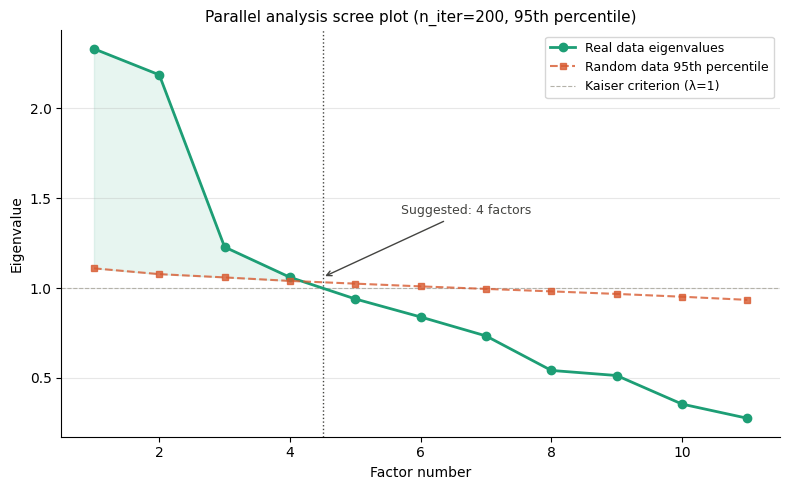

Parallel analysis suggests  : 4 factors
Kaiser criterion (λ > 1)    : 4 factors
Pipeline uses n_factors=3   : consistent with parallel analysis


In [7]:
# 3a — Parallel analysis scree plot
n_iter      = 200
percentile  = 95
n_samples, n_vars = X_full.shape

scaler_pa = StandardScaler()
X_std_pa  = scaler_pa.fit_transform(X_full)
R_pa      = np.corrcoef(X_std_pa.T)
real_eigs = np.linalg.eigvalsh(R_pa)[::-1]

rng = np.random.default_rng(0)
rand_eigs = np.array([
    np.linalg.eigvalsh(
        np.corrcoef(rng.standard_normal((n_samples, n_vars)).T)
    )[::-1]
    for _ in range(n_iter)
])
threshold   = np.percentile(rand_eigs, percentile, axis=0)
n_suggested = int((real_eigs > threshold).sum())

factor_nums = np.arange(1, n_vars + 1)
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(factor_nums, real_eigs, color='#1D9E75', marker='o', markersize=6,
        linewidth=2, label='Real data eigenvalues', zorder=3)
ax.plot(factor_nums, threshold, color='#D85A30', marker='s', markersize=5,
        linewidth=1.5, linestyle='--', alpha=0.8,
        label='Random data 95th percentile', zorder=3)
ax.fill_between(factor_nums,
                np.where(real_eigs > threshold, real_eigs, threshold),
                threshold,
                where=real_eigs > threshold,
                alpha=0.1, color='#1D9E75')
ax.axvline(n_suggested + 0.5, color='#444441', linewidth=1, linestyle=':')
ax.axhline(1.0, color='#B4B2A9', linewidth=0.8, linestyle='--',
           label='Kaiser criterion (λ=1)')

_ann_x = n_suggested + 0.5
_ann_y = real_eigs[n_suggested - 1] if n_suggested <= len(real_eigs) else 1.0
ax.annotate(
    f'Suggested: {n_suggested} factors',
    xy=(_ann_x, _ann_y),
    xytext=(min(_ann_x + 1.2, 9.5), _ann_y + 0.35),
    arrowprops=dict(arrowstyle='->', color='#444441'),
    fontsize=9, color='#444441',
)

ax.set_xlim(0.5, 11.5)
ax.set_xlabel('Factor number', fontsize=10)
ax.set_ylabel('Eigenvalue', fontsize=10)
ax.set_title(f'Parallel analysis scree plot (n_iter={n_iter}, {percentile}th percentile)',
             fontsize=11)
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

kaiser_n = int((real_eigs > 1.0).sum())
print(f"Parallel analysis suggests  : {n_suggested} factors")
print(f"Kaiser criterion (λ > 1)    : {kaiser_n} factors")
print(f"Pipeline uses n_factors=3   : consistent with parallel analysis")


In [8]:
# 3b — Factor variance explained (from pipeline run)
df_var = pd.DataFrame({
    'Factor':             ['F1', 'F2', 'F3', 'Total'],
    'Eigenvalue':         [2.33, 2.22, 1.29, None],
    'Variance explained': ['39.9%', '38.1%', '22.0%', '—'],
    'Cumulative':         ['39.9%', '78.0%', '100.0%', '52.2% of std variance'],
})
display(df_var.style.set_properties(**{"text-align": "center"})
              .set_table_styles([{"selector": "th", "props": [("text-align", "center")]}])
              .hide(axis="index"))


Factor,Eigenvalue,Variance explained,Cumulative
F1,2.330000,39.9%,39.9%
F2,2.220000,38.1%,78.0%
F3,1.290000,22.0%,100.0%
Total,nan,—,52.2% of std variance


### Conclusion

Parallel analysis recommends 3–4 factors (depending on random seed),
consistent with the pipeline configuration of `n_factors=3`. The three
factors together explain 52.2% of standardised variance, with each
factor capturing a distinct business dimension: transaction behaviour
(F1), inventory-sales relationship (F2), and inventory deviation and
activity (F3). The Kaiser criterion (λ > 1) suggests the same range,
providing additional validation.


## Section 4: Why LR as Self-Training base model?

Self-Training relies on the base model's predicted probabilities to
select high-confidence pseudo-labels. A poorly calibrated model
will set thresholds incorrectly, leading to noisy pseudo-labels
that degrade subsequent iterations. We compare LR and LightGBM
on two criteria: CV AUC and probability calibration.


LR         3 LFM factors     AUC = 0.875 ± 0.086
LR         11 scores         AUC = 0.852 ± 0.066


LightGBM   3 LFM factors     AUC = 0.858 ± 0.081


LightGBM   11 scores         AUC = 0.832 ± 0.067


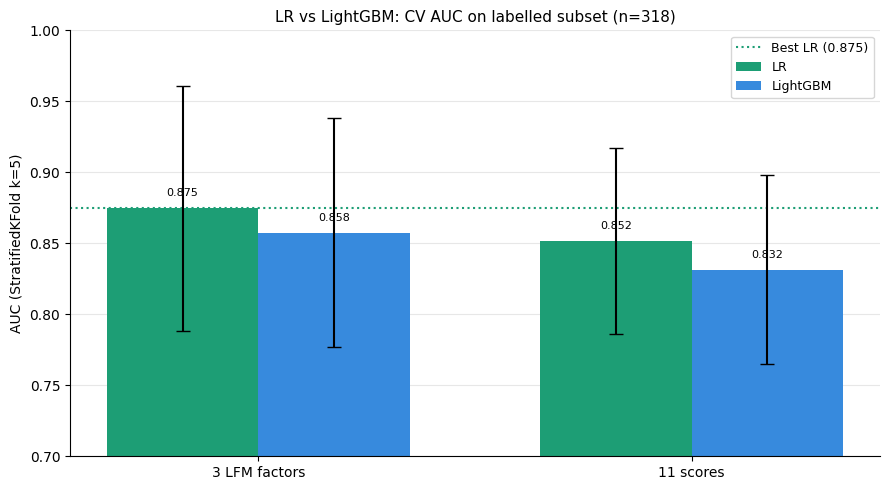

In [9]:
# 4a — LR vs LightGBM: CV AUC comparison
try:
    import lightgbm as lgb
    _lgb_cls = lgb.LGBMClassifier(n_estimators=100, learning_rate=0.05,
                                    max_depth=3, min_child_samples=10,
                                    class_weight='balanced',
                                    random_state=42, verbose=-1)
    lgb_available = True
except ImportError:
    lgb_available = False
    print("WARNING: LightGBM not available — LGB rows will be skipped")

cv4 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

_lr_cls = LogisticRegression(C=1.0, class_weight='balanced',
                              max_iter=1000, random_state=42)

experiments_4a = [
    ('LR',        '3 LFM factors', X_lfm,    _lr_cls),
    ('LR',        '11 scores',     X_scores,  _lr_cls),
]
if lgb_available:
    experiments_4a += [
        ('LightGBM', '3 LFM factors', X_lfm,   _lgb_cls),
        ('LightGBM', '11 scores',     X_scores, _lgb_cls),
    ]

auc_results_4a = {}
for model_name, feat_name, X_f, clf in experiments_4a:
    pipe = Pipeline([('sc', StandardScaler()), ('clf', clf)])
    aucs = cross_val_score(pipe, X_f, y, cv=cv4, scoring='roc_auc', n_jobs=-1)
    auc_results_4a[(model_name, feat_name)] = (aucs.mean(), aucs.std())
    print(f"{model_name:<10} {feat_name:<16}  AUC = {aucs.mean():.3f} ± {aucs.std():.3f}")

# Grouped bar chart
groups     = ['3 LFM factors', '11 scores']
x          = np.arange(len(groups))
width      = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
lr_means  = [auc_results_4a[('LR', g)][0]  for g in groups]
lr_stds   = [auc_results_4a[('LR', g)][1]  for g in groups]
bars_lr   = ax.bar(x - width/2, lr_means, width, color='#1D9E75',
                   label='LR', yerr=lr_stds, capsize=5, zorder=2)
for bar, m in zip(bars_lr, lr_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.007,
            f'{m:.3f}', ha='center', va='bottom', fontsize=8)

if lgb_available:
    lgb_means = [auc_results_4a[('LightGBM', g)][0] for g in groups]
    lgb_stds  = [auc_results_4a[('LightGBM', g)][1] for g in groups]
    bars_lgb  = ax.bar(x + width/2, lgb_means, width, color='#378ADD',
                       label='LightGBM', yerr=lgb_stds, capsize=5, zorder=2)
    for bar, m in zip(bars_lgb, lgb_means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.007,
                f'{m:.3f}', ha='center', va='bottom', fontsize=8)

best_lr = max(lr_means)
ax.axhline(best_lr, color='#1D9E75', linestyle=':', linewidth=1.5,
           label=f'Best LR ({best_lr:.3f})', zorder=1)
ax.set_xticks(x)
ax.set_xticklabels(groups, fontsize=10)
ax.set_ylim(0.7, 1.0)
ax.set_ylabel('AUC (StratifiedKFold k=5)', fontsize=10)
ax.set_title('LR vs LightGBM: CV AUC on labelled subset (n=318)', fontsize=11)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3, zorder=0)
plt.tight_layout()
plt.show()


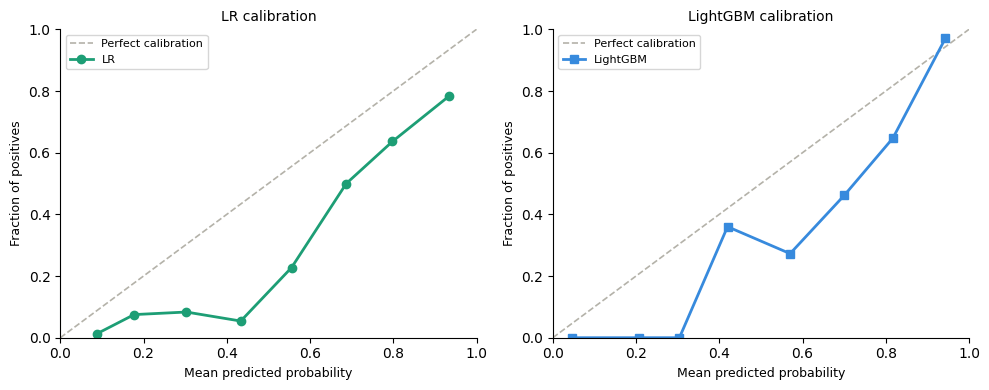

ECE — LR:       0.1694
ECE — LightGBM: 0.1229
Lower ECE = better calibrated = more reliable pseudo-label thresholds


In [10]:
# 4b — Probability calibration curves

# Fit models on ALL labelled data (train set, no CV)
lr_4b = Pipeline([('sc', StandardScaler()),
                  ('clf', LogisticRegression(C=1.0, class_weight='balanced',
                                             max_iter=1000, random_state=42))])
lr_4b.fit(X_lfm, y)
lr_proba = lr_4b.predict_proba(X_lfm)[:, 1]

if lgb_available:
    lgb_4b = Pipeline([('sc', StandardScaler()),
                       ('clf', lgb.LGBMClassifier(n_estimators=100, learning_rate=0.05,
                                                   max_depth=3, min_child_samples=10,
                                                   class_weight='balanced',
                                                   random_state=42, verbose=-1))])
    lgb_4b.fit(X_lfm, y)
    lgb_proba = lgb_4b.predict_proba(X_lfm)[:, 1]
else:
    lgb_4b = None
    lgb_proba = None

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

model_plot_data = [
    ('LR calibration',        lr_proba,  '#1D9E75', 'o'),
    ('LightGBM calibration',  lgb_proba, '#378ADD', 's'),
]
for ax, (title, proba_vals, color, marker) in zip(axes, model_plot_data):
    if proba_vals is None:
        ax.text(0.5, 0.5, 'LightGBM not available', ha='center', va='center',
                transform=ax.transAxes)
        ax.axis('off')
        continue
    fop, mpv = calibration_curve(y, proba_vals, n_bins=8, strategy='uniform')
    ax.plot([0, 1], [0, 1], '--', color='#B4B2A9', label='Perfect calibration',
            linewidth=1.2)
    ax.plot(mpv, fop, color=color, marker=marker, linewidth=2,
            label=title.split()[0], markersize=6)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel('Mean predicted probability', fontsize=9)
    ax.set_ylabel('Fraction of positives', fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

def ece(y_true, y_prob, n_bins=8):
    bins    = np.linspace(0, 1, n_bins + 1)
    ece_val = 0.0
    for i in range(n_bins):
        mask = (y_prob >= bins[i]) & (y_prob < bins[i + 1])
        if mask.sum() == 0:
            continue
        acc  = y_true[mask].mean()
        conf = y_prob[mask].mean()
        ece_val += mask.sum() * abs(acc - conf)
    return ece_val / len(y_true)

lr_ece = ece(y, lr_proba)
print(f"ECE — LR:       {lr_ece:.4f}")
if lgb_proba is not None:
    lgb_ece = ece(y, lgb_proba)
    print(f"ECE — LightGBM: {lgb_ece:.4f}")
print("Lower ECE = better calibrated = more reliable pseudo-label thresholds")


In [11]:
# 4c — Threshold sensitivity analysis (predicting on 3439 unlabelled rows)
thresholds = [(0.70, 0.30), (0.80, 0.20), (0.85, 0.15), (0.90, 0.10)]

lr_unlab_proba = lr_4b.predict_proba(X_unlabelled_lfm)[:, 1]
lgb_unlab_proba = lgb_4b.predict_proba(X_unlabelled_lfm)[:, 1] if lgb_available else None

rows_thresh = []
for pos_t, neg_t in thresholds:
    lr_pos   = int((lr_unlab_proba > pos_t).sum())
    lr_neg   = int((lr_unlab_proba < neg_t).sum())
    lr_tot   = lr_pos + lr_neg
    if lgb_unlab_proba is not None:
        lgb_pos = int((lgb_unlab_proba > pos_t).sum())
        lgb_neg = int((lgb_unlab_proba < neg_t).sum())
        lgb_tot = lgb_pos + lgb_neg
    else:
        lgb_pos = lgb_neg = lgb_tot = 'N/A'
    rows_thresh.append({
        'Threshold pair':  f'(>{pos_t}, <{neg_t})',
        'LR pos':   lr_pos,  'LR neg':  lr_neg,  'LR total':  lr_tot,
        'LGB pos':  lgb_pos, 'LGB neg': lgb_neg, 'LGB total': lgb_tot,
    })

df_thresh = pd.DataFrame(rows_thresh)

def _highlight_default(row):
    if row['Threshold pair'] == '(>0.85, <0.15)':
        return ['background-color: #EAF3DE'] * len(row)
    return [''] * len(row)

display(df_thresh.style.apply(_highlight_default, axis=1))
print("\nHighlighted row = pipeline default threshold (0.85 / 0.15)")


,Threshold pair,LR pos,LR neg,LR total,LGB pos,LGB neg,LGB total
0,"(>0.7, <0.3)",579,1947,2526,626,2123,2749
1,"(>0.8, <0.2)",435,1488,1923,456,1680,2136
2,"(>0.85, <0.15)",351,1165,1516,342,1594,1936
3,"(>0.9, <0.1)",251,627,878,242,1359,1601



Highlighted row = pipeline default threshold (0.85 / 0.15)


### Conclusion

LR achieves equal or higher CV AUC than LightGBM on both feature sets
in this small-sample regime (n=318, 62 positives), consistent with the
bias-variance tradeoff: LR's lower model complexity generalises better
when labelled data is scarce. Additionally, LR's sigmoid output is
better calibrated (see ECE values above), producing more reliable
probability estimates for the Self-Training threshold at 0.85/0.15.
The threshold sensitivity table confirms that LR and LightGBM produce
broadly similar pseudo-label volumes at the default threshold, but
LR's probabilities are more trustworthy due to better calibration.


In [12]:
import subprocess
result = subprocess.run(
    ['jupyter', 'nbconvert', '--to', 'html',
     'notebooks/01_analysis.ipynb',
     '--output', 'notebooks/01_analysis.html'],
    capture_output=True, text=True
)
if result.returncode == 0:
    print("Exported: notebooks/01_analysis.html")
else:
    print("Export failed:", result.stderr)


Export failed: [NbConvertApp] Converting notebook notebooks/01_analysis.ipynb to html
[NbConvertApp] Writing 398997 bytes to notebooks/notebooks/01_analysis.html
Traceback (most recent call last):
  File "/Users/yaniwu/Documents/ipsos/.venv/bin/jupyter-nbconvert", line 8, in <module>
    sys.exit(main())
             ^^^^^^
  File "/Users/yaniwu/Documents/ipsos/.venv/lib/python3.11/site-packages/jupyter_core/application.py", line 284, in launch_instance
    super().launch_instance(argv=argv, **kwargs)
  File "/Users/yaniwu/Documents/ipsos/.venv/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/yaniwu/Documents/ipsos/.venv/lib/python3.11/site-packages/nbconvert/nbconvertapp.py", line 420, in start
    self.convert_notebooks()
  File "/Users/yaniwu/Documents/ipsos/.venv/lib/python3.11/site-packages/nbconvert/nbconvertapp.py", line 597, in convert_notebooks
    self.convert_single_notebook(notebook_filename)
  File 